In [2]:
pip install pandas nltk matplotlib seaborn wordcloud plotly

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import nltk
import matplotlib
print("All good!")

All good!


In [2]:
import pandas as pd

df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 names=['target','ids','date','flag','user','text'])

df = df[['target', 'date', 'text']]
print(df.shape)
print(df.head())

(1600000, 3)
   target                          date  \
0       0  Mon Apr 06 22:19:45 PDT 2009   
1       0  Mon Apr 06 22:19:49 PDT 2009   
2       0  Mon Apr 06 22:19:53 PDT 2009   
3       0  Mon Apr 06 22:19:57 PDT 2009   
4       0  Mon Apr 06 22:19:57 PDT 2009   

                                                text  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [4]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print("Imports done!")

Imports done!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [6]:
df['target'] = df['target'].replace(4, 1)
print(df['target'].value_counts())

target
0    800000
1    800000
Name: count, dtype: int64


In [8]:
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

print("Function ready!")

Function ready!


In [10]:
df['clean_text'] = df['text'].apply(clean_tweet)
print("Cleaning done!")
print(df[['text', 'clean_text']].head(5))

Cleaning done!
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                          clean_text  
0  awww thats bummer shoulda got david carr third...  
1  upset cant update facebook texting might cry r...  
2  dived many times ball managed save rest go bounds  
3                   whole body feels itchy like fire  
4                           behaving im mad cant see  


In [12]:
df = df[df['clean_text'].str.strip() != '']
df = df.dropna(subset=['clean_text'])
print("Final shape:", df.shape)

Final shape: (1592484, 4)


In [14]:
df.to_csv('cleaned_tweets.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [16]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
print("VADER ready!")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\marya\AppData\Roaming\nltk_data...


VADER ready!


In [18]:
sample = "I love this product so much it makes me happy"
score = sia.polarity_scores(sample)
print(score)

{'neg': 0.0, 'neu': 0.47, 'pos': 0.53, 'compound': 0.836}


In [20]:
df['compound_score'] = df['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)
print("Scoring done!")
print(df['compound_score'].head(10))

Scoring done!
0   -0.3818
1   -0.7269
2    0.4939
3   -0.2500
4   -0.4939
5    0.0000
6    0.4767
7    0.8481
8    0.0000
9    0.0000
Name: compound_score, dtype: float64


In [22]:
def get_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['compound_score'].apply(get_sentiment)
print(df['sentiment'].value_counts())

sentiment
positive    760450
neutral     444152
negative    387882
Name: count, dtype: int64


In [24]:
df.to_csv('scored_tweets.csv', index=False)
print("Saved!")
print(df[['text', 'clean_text', 'sentiment', 'compound_score']].head(10))

Saved!
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   
5                      @Kwesidei not the whole crew    
6                                        Need a hug    
7  @LOLTrish hey  long time no see! Yes.. Rains a...   
8               @Tatiana_K nope they didn't have it    
9                          @twittera que me muera ?    

                                          clean_text sentiment  compound_score  
0  awww thats bummer shoulda got david carr third...  negative         -0.3818  
1  upset cant update facebook texting might cry r...  negative         -0.7269  
2  dived many times ball managed save rest go bounds  positive          0.4939  
3                   whole body feels itchy like fire

In [26]:
print(df['sentiment'].value_counts())
print("\nPercentages:")
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

sentiment
positive    760450
neutral     444152
negative    387882
Name: count, dtype: int64

Percentages:
sentiment
positive    47.8
neutral     27.9
negative    24.4
Name: proportion, dtype: float64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

print("Libraries ready!")

Libraries ready!


## Chart 1 — Sentiment Distribution

We analyzed **1,592,484** cleaned tweets and classified each one 
as positive, negative or neutral using VADER sentiment scoring.

The bar chart below shows the overall breakdown of sentiment 
across all tweets.

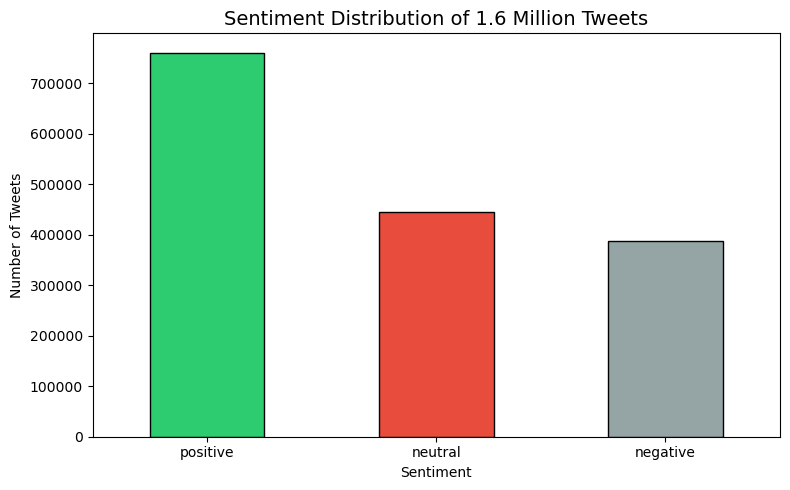

Chart 1 saved!


In [30]:
plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
df['sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Sentiment Distribution of 1.6 Million Tweets', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()
print("Chart 1 saved!")

## Chart 2 — Sentiment Percentage Breakdown

The pie chart below shows the same sentiment distribution 
as a percentage to make it easier to compare proportions at a glance.

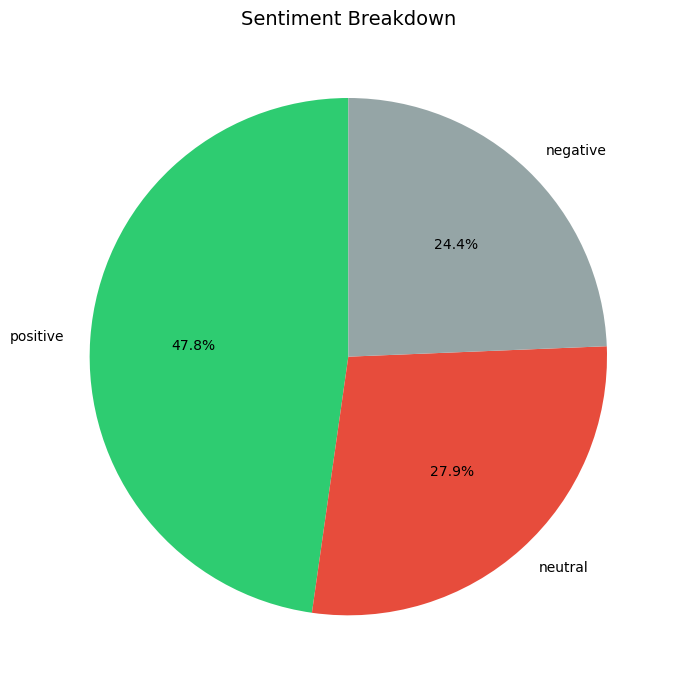

Chart 2 saved!


In [32]:
plt.figure(figsize=(7,7))
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#95a5a6'],
    startangle=90
)
plt.title('Sentiment Breakdown', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.savefig('sentiment_pie.png')
plt.show()
print("Chart 2 saved!")

### Finding
Positive sentiment accounts for nearly half **(47.8%)** of all tweets. 

Combined positive and neutral tweets make up **75.6%** of the dataset 
— showing Twitter was overwhelmingly a positive platform in 2009.

## Chart 3 — Positive Tweets Word Cloud

The word cloud below shows the most frequently used words in tweets 
classified as positive.

> The bigger the word, the more times it appeared in positive tweets.

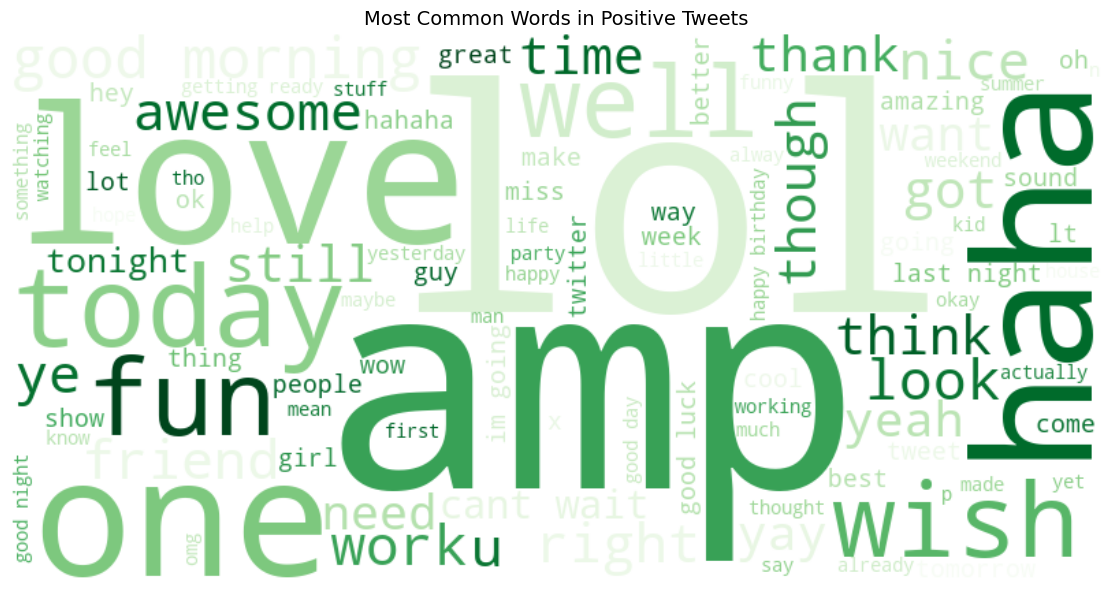

Chart 3 saved!


In [34]:
positive_tweets = ' '.join(
    df[df['sentiment'] == 'positive']['clean_text'].dropna()
)
wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive_tweets)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Tweets', fontsize=14)
plt.tight_layout()
plt.savefig('positive_wordcloud.png')
plt.show()
print("Chart 3 saved!")

### Finding
Words like **love, fun, good, wish** and **happy** dominate 
positive tweets.

This tells us people tweeted positively about:
- Social life and friendships
- Everyday happiness
- Celebrations and good nights out

## Chart 4 - Negative Tweets Word Cloud

The word cloud below shows the most frequently used words 
in tweets classified as negative.

This helps us understand what topics and emotions drive negative sentiment.

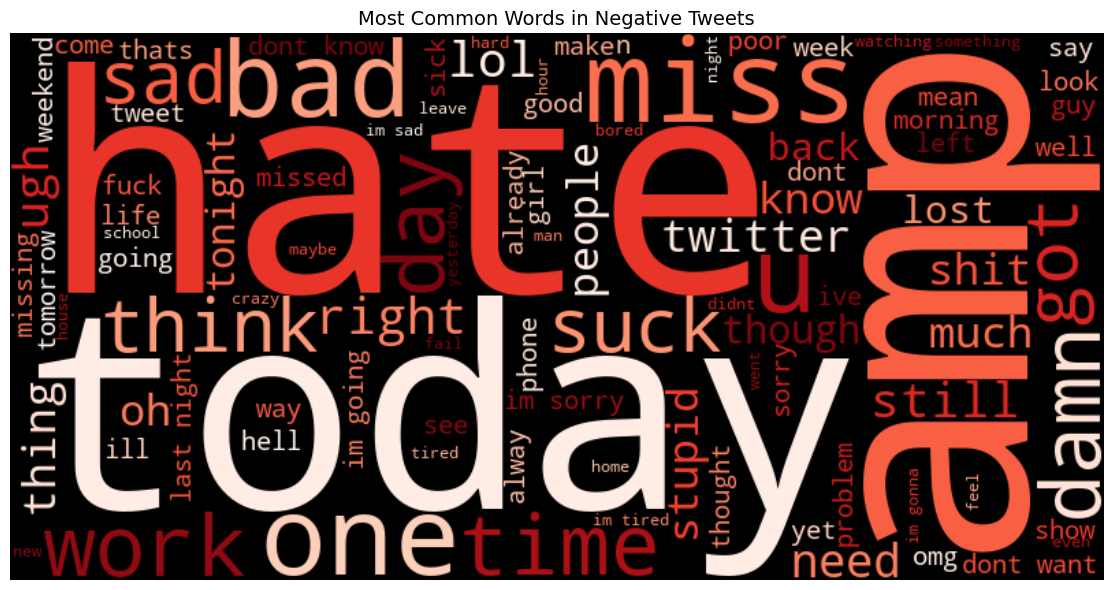

Chart 4 saved!


In [36]:
negative_tweets = ' '.join(
    df[df['sentiment'] == 'negative']['clean_text'].dropna()
)
wordcloud_neg = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    max_words=100
).generate(negative_tweets)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets', fontsize=14)
plt.tight_layout()
plt.savefig('negative_wordcloud.png')
plt.show()
print("Chart 4 saved!")

### Finding
Words like **hate, bad, miss, work** and **suck** appear most 
in negative tweets.

The two biggest themes driving negativity were:
- **Work stress** - people venting about their jobs
- **Missing someone** - longing for friends or family

These are very human complaints that still apply in 2026.

## Chart 5 - Sentiment Trend Over Time

The line chart below tracks how positive, negative and neutral 
tweet counts changed month by month from **April to June 2009**.

This shows whether Twitter's overall mood shifted over time.

C:\Users\marya\AppData\Local\Temp\ipykernel_7040\1229851868.py:1: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


<Figure size 1200x600 with 0 Axes>

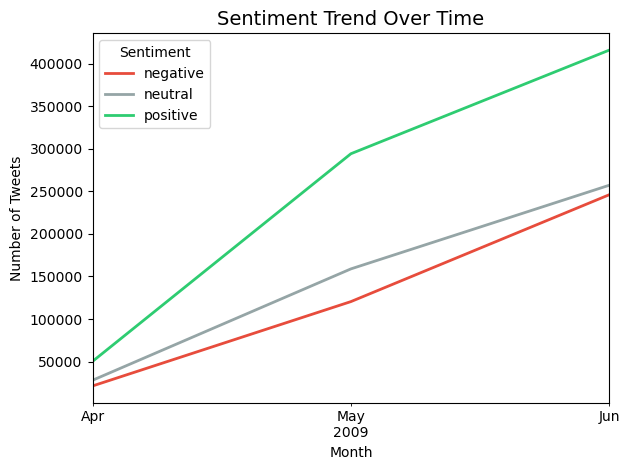

Chart 5 saved!


In [38]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M')

trend = df.groupby(['month', 'sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
trend.plot(
    kind='line',
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    linewidth=2
)
plt.title('Sentiment Trend Over Time', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('sentiment_trend.png')
plt.show()
print("Chart 5 saved!")

### Finding
All three sentiments grew steadily as Twitter's user base expanded.

However **positive tweets grew the fastest** - the gap between 
positive and negative widened from April to June 2009.

This suggests early Twitter users were more likely to share 
good news and happy experiences than complaints.

# Conclusion

This project analyzed **1,592,484 tweets** using Python and 
VADER to understand public sentiment on Twitter.

---

## Results

| Sentiment | Count | Percentage |
|---|---|---|
| Positive | 760,450 | 47.8% |
| Neutral | 444,152 | 27.9% |
| Negative | 387,882 | 24.4% |

---

## What I Found
- Almost **half of all tweets were positive**
- People tweeted positively about **friends, love and daily life**
- Most negative tweets were about **work stress and missing people**
- Positive sentiment grew **faster than negative** from April to June 2009

---

## Limitations
- VADER cannot detect sarcasm
- Dataset is from 2009 so some slang may be missed

---

## What This Can Be Used For
The same pipeline can be applied to any brand or product 
to track customer opinion in real time - for example 
monitoring Zomato tweets to catch delivery complaints early.

---

*Tools used: Python, Pandas, NLTK, VADER, Matplotlib, WordCloud*  
*Dataset: Sentiment140 - Kaggle*